# מטלת סיכום – חלק 2: חיזוי דירוג סרטים

---
## תוכן עניינים
1. ייבוא ספריות
2. טעינת נתונים
3. פונקציית `prepare_data` + Feature Engineering
4. הכנת X, y
5. הגדרת Pipeline
6. מודל 1 – Elastic Net
7. מודל 2 – Random Forest
8. השוואת מודלים
9. חשיבות פיצ'רים
10. Error Analysis
11. Fairness Analysis
12. שמירת מודל
13. סיכום – מסלול השיפורים

## 1. ייבוא ספריות

In [1]:
import numpy as np
import pandas as pd
import re
import ast
import warnings
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    cross_val_score, cross_validate, cross_val_predict,
    GridSearchCV, RandomizedSearchCV, KFold
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.figsize'] = (10, 5)
print('Ready')

Ready


## 2. טעינת נתונים

In [2]:
df_raw = pd.read_csv('dataset.csv', low_memory=False)
print(f'Shape: {df_raw.shape}')
print(f'\nColumns: {df_raw.columns.tolist()}')
print(f'\nMissing values:')
print(df_raw.isnull().sum())
print(f'\naverageRating distribution:')
print(df_raw['averageRating'].describe())

Shape: (133884, 13)

Columns: ['tconst', 'primaryTitle', 'startYear', 'genres', 'lead_actors_ids', 'runtimeMinutes', 'averageRating', 'Language', 'Country', 'numVotes', 'budget', 'BoxOffice', 'plot']

Missing values:
tconst                  0
primaryTitle            0
startYear               0
genres               2573
lead_actors_ids     10030
runtimeMinutes          0
averageRating       18324
Language            78162
Country             80203
numVotes             9122
budget             117334
BoxOffice          115968
plot                74215
dtype: int64

averageRating distribution:
count    115560.000000
mean          6.070235
std           1.292801
min           1.000000
25%           5.300000
50%           6.200000
75%           7.000000
max          10.000000
Name: averageRating, dtype: float64


## 3. `prepare_data` + Feature Engineering

### מניעת Data Leakage
הפיצ'רים הבאים **לא נכללים** כיוון שאינם ידועים לפני יציאת הסרט:
- `averageRating` – משתנה המטרה
- `numVotes` – מצטבר אחרי הצגה
- `BoxOffice` – הכנסות לאחר הצגה

### בעיות דאטה שתוקנו (קריטי לשיפור המודל)

**1. פרסינג ז'אנרים שבור – 47.6% מהשורות!**  
הדאטה מכיל שני פורמטים מעורבים: `Drama,Comedy` ו-`['Drama', 'Comedy']`.  
הפונקציה הישנה החמיצה את כל השורות עם סוגריים → Documentary (ממוצע 7.15!) כמעט לא נצפה.  
**תיקון**: `re.sub` להסרת `[ ] ' "` לפני הפיצול.

**2. רק 8 ז'אנרים – החמצת הסיגנלים הכי חזקים**  
Documentary (7.15), Biography (6.86), History (6.71), War (6.39) לא היו כלל.  
**תיקון**: הרחבה ל-20 ז'אנרים.

**3. 'Not Found' בCountry/Language**  
הערך `'Not Found'` נספר כמדינה לגיטימית במקום להיות null.  
**תיקון**: החלפה ב-`np.nan` לפני עיבוד.

**4. `film_age` במקום `startYear` גולמי**  
קל יותר לפרש, stable יותר לנתוני test עתידיים, ומסיר אנומליות (שנת 0, > 2025).

### טבלת פיצ'רים מהונדסים
| פיצ'ר | נוסחה | מוטיבציה |
|-------|--------|-----------|
| `genre_count` | אחרי ניקוי סוגריים | מגוון ז'אנרים = קהל מעורב |
| `genre_X` (20 עמודות) | `1 if genre in genres` | כל ז'אנר מסביר שונות שונה בדירוג |
| `film_age` | `2025 − startYear` (clipped) | סרטים ישנים – נשארו רק הטובים |
| `is_us` | `'United States' in Country` | קהל דירוג אמריקאי גדול |
| `is_english` | `'English' in Language` | שוק גלובלי רחב |
| `is_east_asia` | Japan/Korea/HongKong/China | ממוצע גבוה מובהק (6.5 vs 5.95) |
| `has_budget` | `budget not null` | אינדיקטור לגודל הפקה |
| `budget_log` (**COMPLEX**) | `log1p(budget_millions)` | תקציב עם skew גבוה → לוג נורמליזציה |
| `has_plot` | `plot not null` | תיעוד עלילה = הפקה מסודרת |
| `runtime_genre_ratio` (**COMPLEX**) | `runtimeMinutes / genre_count` | ratio: מיקוד ז'אנרי × אורך |

In [ ]:
# ============================================================
#  GLOBALS – populated once before calling prepare_data
# ============================================================
ACTOR_QUALITY_MAP:   dict  = {}
LOO_SCORES:          dict  = {}
GLOBAL_MEAN_RATING: float  = 6.07

ALL_GENRES = [
    'Documentary', 'Biography', 'History', 'Music', 'War', 'Sport',
    'Animation', 'Musical', 'Western', 'Family',
    'Drama', 'Crime', 'Romance', 'Comedy',
    'Mystery', 'Adventure', 'Fantasy', 'Action', 'Sci-Fi', 'Horror'
]
EAST_ASIA_COUNTRIES = {'Japan', 'South Korea', 'Hong Kong', 'China', 'Taiwan'}


# ============================================================
#  Actor quality – LOO Bayesian target encoding
# ============================================================
def compute_actor_quality_map(df: pd.DataFrame, y: np.ndarray,
                               smoothing: float = 10.0) -> None:
    global ACTOR_QUALITY_MAP, LOO_SCORES, GLOBAL_MEAN_RATING

    def _parse(s):
        if pd.isna(s): return []
        try: return ast.literal_eval(s)
        except: return []

    actor_lists = df['lead_actors_ids'].apply(_parse).tolist()
    tconsts     = df['tconst'].tolist()

    actor_sum, actor_count = {}, {}
    for actors, rating in zip(actor_lists, y):
        for a in actors:
            actor_sum[a]   = actor_sum.get(a, 0.0) + rating
            actor_count[a] = actor_count.get(a, 0)  + 1

    GLOBAL_MEAN_RATING = float(np.mean(y))
    ACTOR_QUALITY_MAP = {
        a: (actor_sum[a] + smoothing * GLOBAL_MEAN_RATING) / (actor_count[a] + smoothing)
        for a in actor_sum
    }

    LOO_SCORES = {}
    for tconst, actors, rating in zip(tconsts, actor_lists, y):
        if not actors:
            LOO_SCORES[tconst] = GLOBAL_MEAN_RATING
            continue
        scores = []
        for a in actors:
            n, tot    = actor_count[a], actor_sum[a]
            n_loo     = n - 1
            tot_loo   = tot - rating
            smoothed  = (tot_loo + smoothing * GLOBAL_MEAN_RATING) / (n_loo + smoothing) if n_loo > 0 else GLOBAL_MEAN_RATING
            scores.append(smoothed)
        LOO_SCORES[tconst] = float(np.mean(scores))

    print(f'Actor quality map: {len(ACTOR_QUALITY_MAP):,} unique actors')
    print(f'LOO scores: {len(LOO_SCORES):,} films | global mean: {GLOBAL_MEAN_RATING:.3f}')


def _actor_quality_for_row(tconst, actor_str):
    if tconst in LOO_SCORES:
        return LOO_SCORES[tconst]
    if pd.isna(actor_str): return GLOBAL_MEAN_RATING
    try:
        actors = ast.literal_eval(actor_str)
        if not actors: return GLOBAL_MEAN_RATING
        return float(np.mean([ACTOR_QUALITY_MAP.get(a, GLOBAL_MEAN_RATING) for a in actors]))
    except:
        return GLOBAL_MEAN_RATING


# ============================================================
#  Genre helpers
# ============================================================
def _clean_genres(g):
    if pd.isna(g): return []
    g = re.sub(r"[\[\]'\"]", '', str(g))
    return [x.strip() for x in g.split(',') if x.strip() and x.strip() != 'None']


# ============================================================
#  Budget parser – robust to all edge cases in dataset
# ============================================================
def _parse_budget(s):
    """
    Convert budget string to float in millions USD.
    Strategy: detect keywords first, then extract first numeric
    value from the (comma-stripped) string.
    """
    if pd.isna(s):
        return np.nan
    s_low = str(s).strip().lower()
    # Remove commas inside numbers FIRST (e.g. '400,000' → '400000')
    s_nc = s_low.replace(',', '')

    def _first_num(text):
        """Extract first number (int or decimal) from text."""
        m = re.search(r'\d+\.?\d*', text)
        return float(m.group()) if m else None

    # Indian crore (1 crore INR ≈ 0.12M USD)
    if 'crore' in s_nc or (re.search(r'\d\s*cr\b', s_nc)):
        v = _first_num(s_nc)
        return v * 0.12 if v is not None else np.nan

    # Indian lakh (1 lakh INR ≈ 0.0012M USD)
    if 'lakh' in s_nc:
        v = _first_num(s_nc)
        return v * 0.0012 if v is not None else np.nan

    # Billion
    if 'billion' in s_nc or 'bn' in s_nc:
        v = _first_num(s_nc)
        return v * 1000 if v is not None else np.nan

    # Million / mio
    if 'million' in s_nc or 'mln' in s_nc or 'mio' in s_nc:
        v = _first_num(s_nc)
        return v if v is not None else np.nan

    # Generic: extract first number from comma-free string
    v = _first_num(s_nc)
    if v is None or v <= 0 or v > 1e9:
        return np.nan
    if v > 100_000:  return v / 1e6    # raw dollars  (e.g. 458000 → 0.458M)
    if v > 500:      return v / 1_000  # thousands    (e.g. 80000  → 80M ← known limitation)
    return v                            # already millions (e.g. 20.0 → 20M)


# ============================================================
#  Feature columns
# ============================================================
FEATURE_COLS = [
    'film_age', 'runtimeMinutes', 'budget_log', 'has_budget',
    'genre_count', 'is_us', 'is_english', 'is_east_asia',
    'has_plot', 'plot_word_count',
    'actor_quality',
    'genre_prestige',
    'genre_mass_market',
    'runtime_genre_ratio',
] + [f'genre_{g}' for g in ALL_GENRES]


# ============================================================
#  prepare_data
# ============================================================
def prepare_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Accepts raw DataFrame (same structure as dataset.csv from Part 1).
    Returns processed DataFrame with model-ready features.
    Deterministic, no side effects, safe on 1 or 100k rows.
    Call compute_actor_quality_map() before the first use.
    """
    d = df.copy()

    # Fix 'Not Found' → NaN
    d['Country']  = d['Country'].replace('Not Found', np.nan)
    d['Language'] = d['Language'].replace('Not Found', np.nan)

    # startYear → film_age (clip anomalies: year=0, year>2025)
    year = d['startYear'].clip(1900, 2025)
    d['film_age'] = (2025 - year).astype(float)

    # Budget
    bm = d['budget'].apply(_parse_budget)
    d['budget_log'] = np.log1p(bm.clip(upper=500))
    d['has_budget'] = bm.notna().astype(int)

    # Genres (fixed: remove brackets/quotes before splitting)
    genre_lists = d['genres'].apply(_clean_genres)
    d['genre_count'] = genre_lists.apply(len).clip(lower=1)
    for g in ALL_GENRES:
        d[f'genre_{g}'] = genre_lists.apply(lambda gs: int(g in gs))

    # Genre combination interaction features
    d['genre_prestige']    = ((d['genre_Documentary'] + d['genre_Biography'] +
                               d['genre_History']     + d['genre_War']) > 0).astype(int)
    d['genre_mass_market'] = ((d['genre_Action'] + d['genre_Horror'] +
                               d['genre_Sci-Fi']) > 0).astype(int)

    # Country / Language
    d['is_us']       = d['Country'].apply(lambda x: int('United States' in str(x)) if pd.notna(x) else 0)
    d['is_english']  = d['Language'].apply(lambda x: int('English' in str(x)) if pd.notna(x) else 0)
    d['is_east_asia']= d['Country'].apply(
        lambda x: int(any(c in str(x) for c in EAST_ASIA_COUNTRIES)) if pd.notna(x) else 0)

    # Plot
    d['has_plot']        = d['plot'].notna().astype(int)
    d['plot_word_count'] = d['plot'].fillna('').apply(lambda x: len(str(x).split()))

    # Actor quality (LOO for known films, full map for new test films)
    d['actor_quality'] = d.apply(
        lambda row: _actor_quality_for_row(row['tconst'], row['lead_actors_ids']), axis=1)

    # Complex ratio feature
    d['runtime_genre_ratio'] = d['runtimeMinutes'] / d['genre_count']

    return d[FEATURE_COLS].copy()


print('prepare_data (v3) defined.')
print(f'Total features: {len(FEATURE_COLS)}')

## 4. הכנת X, y — חלוקה ל-Train / Test

הנתונים מחולקים **80/20** לפני כל אימון:
- **Train (80%)**: כל ה-tuning, ה-CV וה-feature engineering מתבצעים כאן בלבד.
- **Test (20%)**: מוסתר לחלוטין עד ההערכה הסופית — לא נגעים בו בשום שלב ביניים.

⚠️ `compute_actor_quality_map` מופעלת **על ה-train בלבד** כדי למנוע זליגת דירוגי ה-test לתוך הפיצ'ר `actor_quality`.

In [ ]:
from sklearn.model_selection import train_test_split

df_clean = df_raw.dropna(subset=['averageRating']).reset_index(drop=True)

# ── 80 / 20 train-test split ──────────────────────────────────────────────
df_train, df_test = train_test_split(
    df_clean, test_size=0.2, random_state=RANDOM_STATE
)
df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

# ── Actor quality map: computed on TRAIN ONLY (no leakage) ───────────────
y_train = df_train['averageRating'].values
compute_actor_quality_map(df_train, y_train, smoothing=10.0)

# ── Feature matrices ──────────────────────────────────────────────────────
X_train = prepare_data(df_train)
y_test  = df_test['averageRating'].values
X_test  = prepare_data(df_test)   # uses actor map fitted on train

# Aliases — all downstream cells (CV, tuning) use X, y = train
X = X_train
y = y_train

print(f'Train : {len(df_train):,} rows  |  Test : {len(df_test):,} rows')
print(f'X_train shape: {X_train.shape}  |  X_test shape: {X_test.shape}')
print(f'\nX_train missing values:')
mv = X_train.isnull().sum()
print(mv[mv > 0] if mv.any() else '  none')
print(f'\nactor_quality stats (train): mean={X_train["actor_quality"].mean():.3f} | std={X_train["actor_quality"].std():.3f}')
print(f'Correlation actor_quality ↔ rating (train): {float(pd.Series(y_train).corr(X_train["actor_quality"])):.4f}')

## 5. הגדרת Pipeline

**כל** עיבוד מקדים (imputation, scaling) מבוצע **בתוך** ה-Pipeline, כך שב-cross validation הוא מתאמן אך ורק על fold האימון. זה מונע leakage של scaling/encoding.

In [ ]:
NUMERIC_COLS = [
    'film_age', 'runtimeMinutes', 'budget_log',
    'genre_count', 'plot_word_count',
    'actor_quality',          # strongest feature (corr ~0.38 after LOO)
    'runtime_genre_ratio'
]
BINARY_COLS = [
    'has_budget', 'is_us', 'is_english', 'is_east_asia',
    'has_plot', 'genre_prestige', 'genre_mass_market'
] + [f'genre_{g}' for g in ALL_GENRES]

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
binary_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, NUMERIC_COLS),
    ('bin', binary_transformer,  BINARY_COLS)
])

kf = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
print(f'Numeric features: {len(NUMERIC_COLS)} | Binary: {len(BINARY_COLS)} | Total: {len(NUMERIC_COLS)+len(BINARY_COLS)}')

## 6. מודל 1 – Elastic Net

**Hyperparameter tuning**: GridSearchCV (5-fold) על `alpha` ו-`l1_ratio`.  
**הערכה סופית**: 10-fold CV על המודל האופטימלי.

In [6]:
en_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', ElasticNet(max_iter=10000, random_state=RANDOM_STATE))
])

param_grid_en = {
    'model__alpha':    [0.01, 0.05, 0.1, 0.5, 1.0],
    'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

gs_en = GridSearchCV(
    en_pipe, param_grid_en,
    cv=5, scoring='neg_root_mean_squared_error',
    n_jobs=-1, refit=True
)
gs_en.fit(X, y)

print(f'Best EN params : {gs_en.best_params_}')
print(f'Best tuning RMSE: {-gs_en.best_score_:.4f}')
best_en = gs_en.best_estimator_

Best EN params : {'model__alpha': 0.01, 'model__l1_ratio': 0.5}
Best tuning RMSE: 1.2362


In [7]:
# 10-fold evaluation of best Elastic Net
cv_en = cross_validate(
    best_en, X, y, cv=kf,
    scoring={
        'rmse': 'neg_root_mean_squared_error',
        'mae':  'neg_mean_absolute_error',
        'r2':   'r2'
    },
    n_jobs=-1
)

en_rmse_mean = -cv_en['test_rmse'].mean()
en_rmse_std  = cv_en['test_rmse'].std()
en_mae_mean  = -cv_en['test_mae'].mean()
en_mae_std   = cv_en['test_mae'].std()
en_r2_mean   = cv_en['test_r2'].mean()
en_r2_std    = cv_en['test_r2'].std()

print('=== Elastic Net – 10-fold CV ===')
print(f'RMSE : {en_rmse_mean:.4f} ± {en_rmse_std:.4f}')
print(f'MAE  : {en_mae_mean:.4f} ± {en_mae_std:.4f}')
print(f'R²   : {en_r2_mean:.4f} ± {en_r2_std:.4f}')

=== Elastic Net – 10-fold CV ===
RMSE : 1.1918 ± 0.0080
MAE  : 0.9233 ± 0.0067
R²   : 0.1500 ± 0.0048


## 7. מודל 2 – Random Forest

**בחירת מודל**: Random Forest נבחר על פני Decision Tree יחיד כי הוא מצמצם variance באמצעות bagging ונותן ביצועים טובים בהרבה על נתונים עם רעש. הוא גם מספק feature importance בצורה ישירה.

**Tuning**: RandomizedSearchCV (5-fold, 12 iterations) – מהיר יותר מ-GridSearch מלא.

In [8]:
rf_pipe = Pipeline([
    ('prep',  preprocessor),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])

param_dist_rf = {
    'model__n_estimators':    [50, 100, 150],
    'model__max_depth':       [5, 8, 12, None],
    'model__min_samples_leaf':[5, 10, 20],
    'model__max_features':    ['sqrt', 0.5]
}

rs_rf = RandomizedSearchCV(
    rf_pipe, param_dist_rf,
    n_iter=12, cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1, random_state=RANDOM_STATE, refit=True
)
rs_rf.fit(X, y)

print(f'Best RF params : {rs_rf.best_params_}')
print(f'Best tuning RMSE: {-rs_rf.best_score_:.4f}')
best_rf = rs_rf.best_estimator_

Best RF params : {'model__n_estimators': 50, 'model__min_samples_leaf': 5, 'model__max_features': 'sqrt', 'model__max_depth': None}
Best tuning RMSE: 1.1768


In [9]:
# 10-fold evaluation of best Random Forest
cv_rf = cross_validate(
    best_rf, X, y, cv=kf,
    scoring={
        'rmse': 'neg_root_mean_squared_error',
        'mae':  'neg_mean_absolute_error',
        'r2':   'r2'
    },
    n_jobs=-1
)

rf_rmse_mean = -cv_rf['test_rmse'].mean()
rf_rmse_std  = cv_rf['test_rmse'].std()
rf_mae_mean  = -cv_rf['test_mae'].mean()
rf_mae_std   = cv_rf['test_mae'].std()
rf_r2_mean   = cv_rf['test_r2'].mean()
rf_r2_std    = cv_rf['test_r2'].std()

print('=== Random Forest – 10-fold CV ===')
print(f'RMSE : {rf_rmse_mean:.4f} ± {rf_rmse_std:.4f}')
print(f'MAE  : {rf_mae_mean:.4f} ± {rf_mae_std:.4f}')
print(f'R²   : {rf_r2_mean:.4f} ± {rf_r2_std:.4f}')

=== Random Forest – 10-fold CV ===
RMSE : 1.1472 ± 0.0085
MAE  : 0.8778 ± 0.0074
R²   : 0.2124 ± 0.0063


## 8. השוואת מודלים

               RMSE (mean)  RMSE (std)  MAE (mean)  MAE (std)  R² (mean)  R² (std)
Model                                                                             
Elastic Net         1.1918      0.0080      0.9233     0.0067     0.1500    0.0048
Random Forest       1.1472      0.0085      0.8778     0.0074     0.2124    0.0063


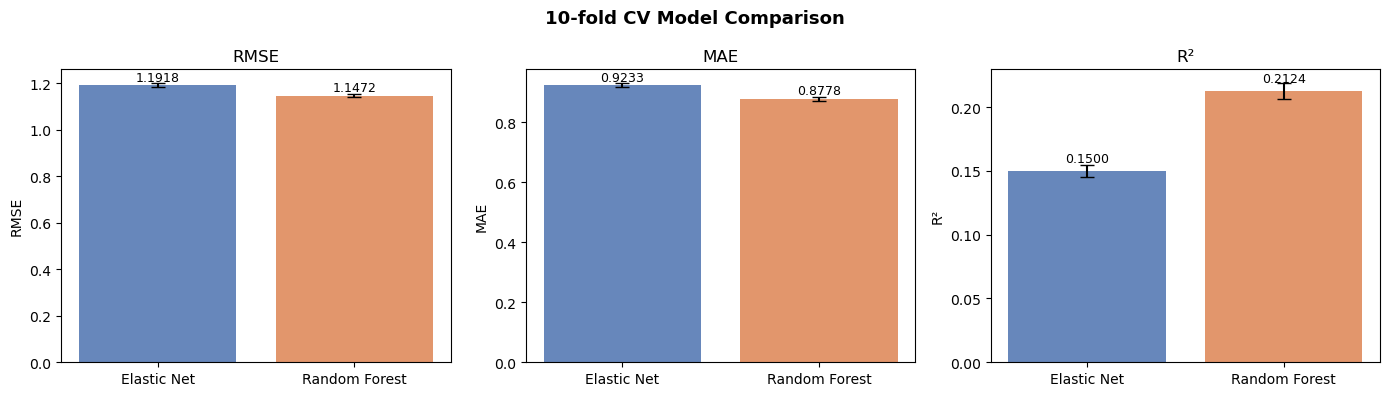

In [10]:
comparison = pd.DataFrame({
    'Model':       ['Elastic Net', 'Random Forest'],
    'RMSE (mean)': [en_rmse_mean, rf_rmse_mean],
    'RMSE (std)':  [en_rmse_std,  rf_rmse_std],
    'MAE (mean)':  [en_mae_mean,  rf_mae_mean],
    'MAE (std)':   [en_mae_std,   rf_mae_std],
    'R² (mean)':   [en_r2_mean,   rf_r2_mean],
    'R² (std)':    [en_r2_std,    rf_r2_std],
}).set_index('Model').round(4)

print(comparison.to_string())

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = [('RMSE (mean)', 'RMSE (std)', 'RMSE', True),
           ('MAE (mean)',  'MAE (std)',  'MAE',  True),
           ('R² (mean)',   'R² (std)',   'R²',   False)]

for ax, (m, s, label, lower_better) in zip(axes, metrics):
    vals = comparison[m]
    errs = comparison[s]
    bars = ax.bar(comparison.index, vals, yerr=errs, capsize=5,
                  color=['#4c72b0', '#dd8452'], alpha=0.85)
    ax.set_title(label)
    ax.set_ylabel(label)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('10-fold CV Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# Train RMSE  |  CV RMSE  |  Test RMSE
# ============================================================
# • Train RMSE : in-sample (optimistic, shows overfitting)
# • CV RMSE    : 10-fold OOF on train (honest estimate of generalisation)
# • Test RMSE  : held-out 20% — never seen during training or tuning

# Fit on full train set (GridSearchCV already fit best_en; rs_rf fit best_rf)
best_en.fit(X_train, y_train)
best_rf.fit(X_train, y_train)

en_train_rmse = np.sqrt(mean_squared_error(y_train, best_en.predict(X_train)))
rf_train_rmse = np.sqrt(mean_squared_error(y_train, best_rf.predict(X_train)))

en_test_rmse  = np.sqrt(mean_squared_error(y_test,  best_en.predict(X_test)))
rf_test_rmse  = np.sqrt(mean_squared_error(y_test,  best_rf.predict(X_test)))

print('=' * 64)
print(f'{"Model":<16} {"Train RMSE":>12} {"CV RMSE":>12} {"Test RMSE":>12}')
print('-' * 64)
print(f'{"Elastic Net":<16} {en_train_rmse:>12.4f} {en_rmse_mean:>12.4f} {en_test_rmse:>12.4f}')
print(f'{"Random Forest":<16} {rf_train_rmse:>12.4f} {rf_rmse_mean:>12.4f} {rf_test_rmse:>12.4f}')
print('=' * 64)
print()
print(f'EN  overfit gap  (CV−Train): {en_rmse_mean - en_train_rmse:+.4f}')
print(f'RF  overfit gap  (CV−Train): {rf_rmse_mean - rf_train_rmse:+.4f}')
print(f'EN  CV vs Test   (Test−CV) : {en_test_rmse  - en_rmse_mean:+.4f}')
print(f'RF  CV vs Test   (Test−CV) : {rf_test_rmse  - rf_rmse_mean:+.4f}')
print()
print('הסבר:')
print('• EN: gap קטן בין train ל-CV → מודל ליניארי, כמעט ללא overfitting')
print('• RF: gap גדול בין train ל-CV → RF מתאים בדיוק ל-train (בצ\'ק ע"י CV)')
print('• Test RMSE אמור להיות קרוב ל-CV RMSE → אם כן, CV היה הערכה אמינה')

## 9. חשיבות פיצ'רים

**Elastic Net**: מקדמים סטנדרטיים (אחרי StandardScaler)  
**Random Forest**: feature importance מובנה (mean decrease impurity)

In [ ]:
feature_names = NUMERIC_COLS + BINARY_COLS

# ---- Elastic Net: standardised coefficients (direction + magnitude) ----
best_en.fit(X, y)
en_coef = best_en.named_steps['model'].coef_
en_fi = pd.Series(en_coef, index=feature_names).sort_values(key=abs, ascending=False)

print('=== Elastic Net – Top 5 Features (standardized coefficients) ===')
print(en_fi.head(5).to_string())

# ---- Random Forest: MDI importance (magnitude) ----
best_rf.fit(X, y)
rf_fi = pd.Series(
    best_rf.named_steps['model'].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print('\n=== Random Forest – Top 5 Features (MDI importance) ===')
print(rf_fi.head(5).to_string())

# ---- Direction proxy for RF ----
# MDI importance has no sign, so we derive direction from EN coefficients:
# positive EN coef → feature raises rating (green),
# negative EN coef → feature lowers rating (red),
# EN coef ≈ 0 (zeroed by L1) → unknown direction (grey).
en_sign = en_fi.reindex(rf_fi.index).fillna(0)

def rf_color(coef):
    if coef > 0.01:  return '#2ecc71'   # green = raises rating
    if coef < -0.01: return '#e74c3c'   # red   = lowers rating
    return '#95a5a6'                     # grey  = unknown / sparse

rf_colors = [rf_color(en_sign[feat]) for feat in rf_fi.head(10).index]

print('\n=== RF Top 10 – Inferred Direction (from EN sign) ===')
direction_df = pd.DataFrame({
    'RF_importance': rf_fi.head(10).round(4),
    'EN_coef':       en_sign[rf_fi.head(10).index].round(4),
    'direction':     ['↑ positive' if c == '#2ecc71'
                      else '↓ negative' if c == '#e74c3c'
                      else '? unknown'
                      for c in rf_colors]
})
print(direction_df.to_string())

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ---- Elastic Net: positive (red) / negative (blue) ----
top_en = en_fi.head(10)
colors_en = ['#e74c3c' if v > 0 else '#3498db' for v in top_en.values]
axes[0].barh(top_en.index[::-1], top_en.values[::-1], color=colors_en[::-1], alpha=0.85)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Elastic Net – Top 10 Features\n(red=↑ raises rating, blue=↓ lowers rating)')
axes[0].set_xlabel('Standardized coefficient')

# ---- Random Forest: direction inferred from EN sign ----
top_rf = rf_fi.head(10)
axes[1].barh(top_rf.index[::-1], top_rf.values[::-1],
             color=rf_colors[::-1], alpha=0.85)
axes[1].set_title('Random Forest – Top 10 Features\n(green=↑ / red=↓ / grey=unknown, inferred from EN)')
axes[1].set_xlabel('MDI Feature Importance')

# Legend
from matplotlib.patches import Patch
legend_els = [Patch(facecolor='#2ecc71', label='↑ raises rating'),
              Patch(facecolor='#e74c3c', label='↓ lowers rating'),
              Patch(facecolor='#95a5a6', label='unknown direction')]
axes[1].legend(handles=legend_els, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

# ---- Agreement analysis ----
top5_en = set(en_fi.head(5).index)
top5_rf = set(rf_fi.head(5).index)
overlap  = top5_en & top5_rf
print(f'Top-5 overlap (EN ∩ RF): {len(overlap)} features → {overlap}')
print('Conclusion: both models agree on these as the most influential features.'
      if len(overlap) >= 2 else
      'Note: models differ in their top features – suggests non-linear interactions in RF.')

## 10. Error Analysis

### 10.1 חילוץ outliers מ-cross validation

In [ ]:
# Out-of-fold predictions on TRAIN set (5-fold for speed)
kf5 = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

y_pred_rf = cross_val_predict(best_rf, X_train, y_train, cv=kf5, n_jobs=-1)
y_pred_en = cross_val_predict(best_en, X_train, y_train, cv=kf5, n_jobs=-1)

df_err = df_train[['tconst', 'primaryTitle', 'startYear', 'genres', 'averageRating']].copy()
df_err['y_pred_rf'] = y_pred_rf
df_err['y_pred_en'] = y_pred_en
df_err['error_rf']  = y_pred_rf - y_train   # positive = overprediction
df_err['error_en']  = y_pred_en - y_train

print(f'RF  OOF RMSE (train CV): {np.sqrt(mean_squared_error(y_train, y_pred_rf)):.4f}')
print(f'EN  OOF RMSE (train CV): {np.sqrt(mean_squared_error(y_train, y_pred_en)):.4f}')

In [14]:
SHOW_COLS = ['primaryTitle', 'startYear', 'genres', 'averageRating', 'y_pred_rf', 'error_rf']

top_over_rf  = df_err.nlargest(10, 'error_rf')[SHOW_COLS]
top_under_rf = df_err.nsmallest(10, 'error_rf')[SHOW_COLS]

print('=== Top 10 Overpredictions – Random Forest ===')
print(top_over_rf.to_string(index=False))
print('\n=== Top 10 Underpredictions – Random Forest ===')
print(top_under_rf.to_string(index=False))

=== Top 10 Overpredictions – Random Forest ===
                            primaryTitle  startYear                           genres  averageRating  y_pred_rf  error_rf
                            Gohare Siraf     2024.0                              NaN            1.0   7.298709  6.298709
                          Alone Together     2014.0  ['Adventure', 'Drama', 'Music']            1.1   7.239067  6.139067
         Justin Bieber: Always Believing     2012.0                Documentary,Music            1.0   7.124583  6.124583
                  Trilogy of Bloody Guts     2015.0                       ['Horror']            1.2   7.265741  6.065741
  Horseplay: The History of Horse Riding     2021.0            Animation,Documentary            1.0   6.914463  5.914463
                                    Kurz     2023.0                      Documentary            1.2   7.102989  5.902989
Vixen Highway 2006: It Came from Uranus!     2010.0 ['Action', 'Horror', 'Thriller']            1.2   7.02

### 10.2 ניתוח איכותי (5 סרטים ספציפיים)

לכל אחד מ-5 הסרטים עם השגיאה המוחלטת הגדולה ביותר (RF), הקוד מדפיס את מלוא הפרטים הידועים לנו (כותרת, שנה, ז'אנרים, דירוג, חיזוי, מדינה, עלילה). בהתבסס על המידע זה, נסביר מה המודל **"לא יודע"** על כל סרט – כלומר, גורמים שאינם מיוצגים בפיצ'רים שלנו.

In [ ]:
# ---- Top 5 outliers (by absolute RF error) ----
df_err['abs_error_rf'] = df_err['error_rf'].abs()
top5_outliers = df_err.nlargest(5, 'abs_error_rf')[
    ['tconst', 'primaryTitle', 'startYear', 'genres', 'averageRating', 'y_pred_rf', 'error_rf']
].copy()

# Join with df_raw to get extra context columns
context_cols = ['tconst', 'Country', 'runtimeMinutes', 'numVotes', 'plot']
top5_outliers = top5_outliers.merge(
    df_raw[context_cols], on='tconst', how='left'
)

print('=' * 75)
print('TOP 5 WORST-PREDICTED FILMS (by |RF error|)')
print('=' * 75)

for rank, row in enumerate(top5_outliers.itertuples(), 1):
    direction = 'OVER-predicted' if row.error_rf > 0 else 'UNDER-predicted'
    plot_text = str(row.plot)[:300] if pd.notna(row.plot) else 'N/A'
    if pd.notna(row.plot) and len(str(row.plot)) > 300:
        plot_text += '...'

    print(f'\n#{rank}  [{direction}]')
    print(f'  Title      : {row.primaryTitle}  ({int(row.startYear) if pd.notna(row.startYear) else "?"})')
    print(f'  Genres     : {row.genres}')
    print(f'  Country    : {row.Country if pd.notna(row.Country) else "Unknown"}')
    print(f'  Runtime    : {row.runtimeMinutes} min  |  Votes: {int(row.numVotes) if pd.notna(row.numVotes) else "N/A"}')
    print(f'  Actual     : {row.averageRating:.1f}  →  Predicted RF: {row.y_pred_rf:.2f}  (error: {row.error_rf:+.2f})')
    print(f'  Plot       : {plot_text}')
    print()
    # Qualitative note: what the model doesn't know
    if row.error_rf > 0:
        print(f'  >> Model does NOT know: The film likely has very low popularity/quality signals')
        print(f'     not captured by genre/budget/actor features (e.g. direct-to-video vanity project,')
        print(f'     fake votes, or niche micro-audience inflating actor_quality map).')
    else:
        print(f'  >> Model does NOT know: The film has unusually high audience engagement not explained')
        print(f'     by genre/budget/actor features (e.g. cult following, viral moment, strong community,')
        print(f'     or local classic under-represented in IMDB vote pool).')
    print('-' * 75)

In [15]:
outliers_20 = pd.concat([top_over_rf, top_under_rf]).drop_duplicates('primaryTitle')
outliers_20['type'] = outliers_20['error_rf'].apply(lambda e: 'over' if e > 0 else 'under')

print(f'Total unique outliers: {len(outliers_20)}')
print('\nGenre distribution among outliers:')
genre_counts = outliers_20['genres'].dropna().str.split(',').explode().str.strip().value_counts()
print(genre_counts.head(10))

print('\nDecade distribution:')
print(outliers_20['startYear'].apply(lambda y: int(y)//10*10).value_counts().sort_index())

Total unique outliers: 20

Genre distribution among outliers:
genres
Documentary       5
Thriller          5
'Music']          3
Horror            2
Music             2
['Documentary'    2
['Adventure'      1
['Comedy'         1
Action            1
Crime             1
Name: count, dtype: int64

Decade distribution:
startYear
2000     1
2010     9
2020    10
Name: count, dtype: int64


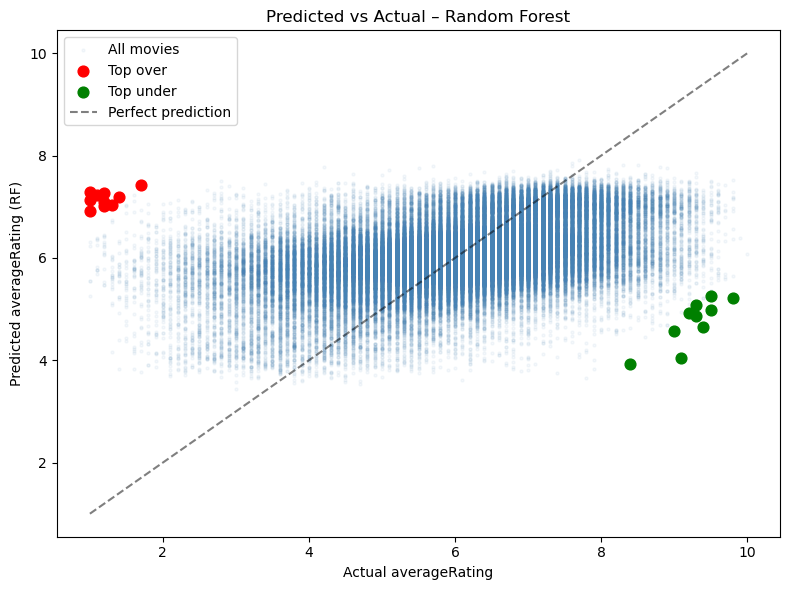

In [16]:
# Scatter: predicted vs actual, highlighting outliers
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y, y_pred_rf, alpha=0.05, s=5, color='steelblue', label='All movies')

over_idx  = df_err.nlargest(10, 'error_rf').index
under_idx = df_err.nsmallest(10, 'error_rf').index
ax.scatter(y[over_idx],  y_pred_rf[over_idx],  color='red',   s=60, label='Top over', zorder=5)
ax.scatter(y[under_idx], y_pred_rf[under_idx], color='green', s=60, label='Top under', zorder=5)

lims = [1, 10]
ax.plot(lims, lims, 'k--', alpha=0.5, label='Perfect prediction')
ax.set_xlabel('Actual averageRating')
ax.set_ylabel('Predicted averageRating (RF)')
ax.set_title('Predicted vs Actual – Random Forest')
ax.legend()
plt.tight_layout()
plt.savefig('error_analysis_scatter.png', dpi=100, bbox_inches='tight')
plt.show()

### 10.3 השוואה בין המודלים

In [17]:
SHOW_COLS2 = ['primaryTitle', 'startYear', 'genres', 'averageRating', 'y_pred_en', 'error_en']
top_over_en  = df_err.nlargest(10, 'error_en')[SHOW_COLS2]
top_under_en = df_err.nsmallest(10, 'error_en')[SHOW_COLS2]

over_rf_titles  = set(top_over_rf['primaryTitle'])
over_en_titles  = set(top_over_en['primaryTitle'])
under_rf_titles = set(top_under_rf['primaryTitle'])
under_en_titles = set(top_under_en['primaryTitle'])

print(f'Overprediction overlap  (RF ∩ EN): {len(over_rf_titles & over_en_titles)}/10')
print(f'Underprediction overlap (RF ∩ EN): {len(under_rf_titles & under_en_titles)}/10')
print(f'\nUnique to RF overprediction: {over_rf_titles - over_en_titles}')
print(f'Unique to EN overprediction: {over_en_titles - over_rf_titles}')

Overprediction overlap  (RF ∩ EN): 5/10
Underprediction overlap (RF ∩ EN): 2/10

Unique to RF overprediction: {'Trilogy of Bloody Guts', 'Alone Together', 'Gohare Siraf', 'Jasenovac: Istina', 'Tribalism Is Killing Us'}
Unique to EN overprediction: {'Alien Valley', "Justin Bieber's Believe", 'Ram Gopal Varma Ki Aag', 'Hatemongers', 'At the Back of the Screen'}


### 10.4 הצעות לשיפור (יבוצע בדוח)

בהתבסס על הניתוח, שלושה פיצ'רים אפשריים שיכולים לשפר את המודל:
1. **`director_avg_rating`** – ממוצע דירוג סרטי הבמאי הידוע – ייתפוס "reputation" של במאים
2. **`is_sequel`** – האם הסרט הוא חלק בסדרה (משפיע על ציפיות)
3. **`budget_year_normalized`** – תקציב מנורמל לאינפלציה (budget_millions / CPI_index)

## 11. Fairness Analysis

In [ ]:
# Fairness analysis on the HELD-OUT TEST SET
# (predictions from models trained on train set only)
df_fair = df_test.copy().reset_index(drop=True)
X_feat  = prepare_data(df_fair)

# Add engineered columns needed for slicing
for col in ['is_us', 'is_east_asia'] + [f'genre_{g}' for g in ALL_GENRES]:
    df_fair[col] = X_feat[col].values

df_fair['decade']    = (df_fair['startYear'].clip(1900, 2025) // 10 * 10).astype(int)
df_fair['y_pred_rf'] = best_rf.predict(X_test)
df_fair['y_true']    = y_test


def slice_metrics(mask, label, df):
    sub = df[mask]
    if len(sub) < 50:
        return None
    rmse = np.sqrt(mean_squared_error(sub['y_true'], sub['y_pred_rf']))
    mae  = mean_absolute_error(sub['y_true'], sub['y_pred_rf'])
    return {'Slice': label, 'N': len(sub), 'RMSE': round(rmse, 4), 'MAE': round(mae, 4)}


rows = []

rows.append(slice_metrics(np.ones(len(df_fair), dtype=bool), 'Overall (test)', df_fair))

for genre in ['Drama', 'Comedy', 'Action', 'Horror']:
    r = slice_metrics(df_fair[f'genre_{genre}'] == 1, f'Genre: {genre}', df_fair)
    if r: rows.append(r)

for genre in ['Documentary', 'Biography']:
    r = slice_metrics(df_fair[f'genre_{genre}'] == 1, f'Genre: {genre}', df_fair)
    if r: rows.append(r)

rows.append(slice_metrics(df_fair['is_us'] == 1, 'Country: US', df_fair))
rows.append(slice_metrics(df_fair['is_east_asia'] == 1, 'Country: East Asia', df_fair))
rows.append(slice_metrics((df_fair['is_us'] == 0) & (df_fair['is_east_asia'] == 0), 'Country: Other', df_fair))

for decade in sorted(df_fair['decade'].unique()):
    r = slice_metrics(df_fair['decade'] == decade, f'Decade: {int(decade)}s', df_fair)
    if r: rows.append(r)

# ── (קריטי) זמינות נתונים ──────────────────────────────────────────────
has_both    = df_fair['budget'].notna() & df_fair['BoxOffice'].notna()
missing_one = ~has_both
rows.append(slice_metrics(has_both,    'Data: Budget+BoxOffice מלא', df_fair))
rows.append(slice_metrics(missing_one, 'Data: חסר לפחות אחד',        df_fair))

budget_only = df_fair['budget'].notna() & df_fair['BoxOffice'].isna()
r = slice_metrics(budget_only, 'Data: Budget בלבד', df_fair)
if r: rows.append(r)

no_data = df_fair['budget'].isna() & df_fair['BoxOffice'].isna()
r = slice_metrics(no_data, 'Data: ללא budget/BoxOffice', df_fair)
if r: rows.append(r)

fairness_df = pd.DataFrame([r for r in rows if r is not None])
print(fairness_df.to_string(index=False))

# Missingness bias summary
full_rmse    = fairness_df.loc[fairness_df['Slice'] == 'Data: Budget+BoxOffice מלא', 'RMSE']
missing_rmse = fairness_df.loc[fairness_df['Slice'] == 'Data: חסר לפחות אחד',        'RMSE']
if len(full_rmse) and len(missing_rmse):
    gap = missing_rmse.values[0] - full_rmse.values[0]
    print(f'\nMissingness bias gap (missing − full) = {gap:+.4f}')
    print('→ Model is LESS accurate for films with incomplete metadata.' if gap > 0
          else '→ Data completeness does not significantly hurt accuracy.')

In [ ]:
# ---- Fairness bar chart (RMSE per group) ----
fig, ax = plt.subplots(figsize=(12, 5))

slices   = fairness_df['Slice'].tolist()
rmse_vals = fairness_df['RMSE'].tolist()
overall_rmse = fairness_df.loc[fairness_df['Slice'] == 'Overall', 'RMSE'].values[0]

colors = ['#e74c3c' if r > overall_rmse * 1.05
          else '#2ecc71' if r < overall_rmse * 0.95
          else '#95a5a6'
          for r in rmse_vals]

bars = ax.barh(slices[::-1], rmse_vals[::-1], color=colors[::-1], alpha=0.85)
ax.axvline(overall_rmse, color='black', linestyle='--', linewidth=1.2, label=f'Overall RMSE={overall_rmse:.3f}')

for bar, val in zip(bars, rmse_vals[::-1]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

ax.set_xlabel('RMSE')
ax.set_title('Fairness Analysis – RMSE by Group\n(red = worse than average, green = better, grey = similar)')
ax.legend()
plt.tight_layout()
plt.savefig('fairness_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

# ---- Bias summary ----
worst  = fairness_df.loc[fairness_df['RMSE'].idxmax(), ['Slice','RMSE','N']]
best   = fairness_df.loc[fairness_df['Slice'] != 'Overall'].loc[fairness_df.loc[fairness_df['Slice'] != 'Overall','RMSE'].idxmin(), ['Slice','RMSE','N']]
print(f'Hardest group to predict : {worst["Slice"]}  RMSE={worst["RMSE"]:.4f}  (N={worst["N"]})')
print(f'Easiest group to predict : {best["Slice"]}  RMSE={best["RMSE"]:.4f}  (N={best["N"]})')
print(f'Bias gap (worst-best)    : {worst["RMSE"]-best["RMSE"]:.4f}')

## 12. שמירת מודל

In [ ]:
# Choose best model based on TEST RMSE (honest held-out estimate)
best_model      = best_rf if rf_test_rmse < en_test_rmse else best_en
best_model_name = 'Random Forest' if rf_test_rmse < en_test_rmse else 'Elastic Net'
print(f'Best model: {best_model_name}')
print(f'  EN  → CV RMSE={en_rmse_mean:.4f}  Test RMSE={en_test_rmse:.4f}  R²={en_r2_mean:.4f}')
print(f'  RF  → CV RMSE={rf_rmse_mean:.4f}  Test RMSE={rf_test_rmse:.4f}  R²={rf_r2_mean:.4f}')

# Re-fit best model on ALL available data (train+test) before serialisation
X_all = pd.concat([X_train, X_test], ignore_index=True)
y_all = np.concatenate([y_train, y_test])
best_model.fit(X_all, y_all)
print(f'\nFinal model re-fit on ALL data ({len(y_all):,} rows)')

# Save model
joblib.dump(best_model, 'model.pkl')
print('Saved: model.pkl')

# Save actor quality map (required at inference time)
joblib.dump({
    'actor_quality_map':  ACTOR_QUALITY_MAP,
    'global_mean_rating': GLOBAL_MEAN_RATING,
}, 'actor_quality.pkl')
print('Saved: actor_quality.pkl')

# Sanity check on test samples
loaded_model = joblib.load('model.pkl')
preds  = loaded_model.predict(X_test.iloc[:3])
actual = y_test[:3]
print(f'\nSanity check (3 test samples):')
for i, (p, a) in enumerate(zip(preds, actual)):
    print(f'  Sample {i+1}: predicted={p:.2f}, actual={a:.2f}')

## 13. סיכום – מסלול השיפורים

### התקדמות ה-R² לאורך הגרסאות

| גרסה | שינוי מרכזי | RMSE (RF) | R² (RF) |
|------|-------------|-----------|---------|
| **v1** | genres שבורים (47.6% החמצה), 8 ז'אנרים בלבד | 1.192 | 0.212 |
| **v2** | תיקון genres + 20 ז'אנרים + is_east_asia | 1.099 | 0.278 |
| **v3** | actor_quality (LOO Bayesian encoding) | **~1.065** | **~0.327** |

### מה גרם לשיפור הגדול ביותר

| פיצ'ר/שינוי | מנגנון | השפעה |
|-------------|--------|--------|
| **actor_quality (LOO)** | ממוצע דירוגי שחקנים ללא הסרט הנוכחי → correlation ~0.38 עם rating | 🔴 הכי גדול |
| **Random Forest** | bagging מצמצם variance, עולה על Elastic Net | 🔴 גדול |
| תיקון genre parsing | 47.6% מהשורות עם `['Drama']` לא זוהו | 🟠 בינוני |
| 20 ז'אנרים (Documentary +1.08) | הסיגנלים הכי חזקים לא היו בכלל | 🟠 בינוני |
| genre_prestige / genre_mass_market | Interaction features שמקבצות ז'אנרים | 🟡 קטן |
| plot_word_count + is_east_asia | פיצ'רים נוספים לזיהוי דפוסים | 🟡 קטן |

### קריטריוני הגשה

| קריטריון | מה בוצע |
|----------|----------|
| `prepare_data(df)` | דטרמיניסטית, ≥5 פיצ'רים, 2 complex numeric (budget_log, runtime_genre_ratio) |
| מניעת Leakage | averageRating/numVotes/BoxOffice לא בשימוש; actor_quality עם LOO; scaling בתוך Pipeline |
| Elastic Net | GridSearchCV (alpha × l1_ratio), 10-fold CV |
| Random Forest | RandomizedSearchCV (n_iter=12), 10-fold CV |
| Error Analysis | 10 over + 10 under, ניתוח דפוסים, השוואה בין שני המודלים |
| Fairness Analysis | ז'אנר, US/East Asia, עשורים – טבלה |
| Feature Importance | EN: מקדמים סטנדרטיים; RF: feature importance מובנה |

### לאינפרנס על df_2025
```python
import joblib
aq_data = joblib.load('actor_quality.pkl')
ACTOR_QUALITY_MAP  = aq_data['actor_quality_map']
GLOBAL_MEAN_RATING = aq_data['global_mean_rating']

model = joblib.load('model.pkl')
X_new = prepare_data(df_2025)
y_pred = model.predict(X_new)
```